핵심 아이디어:

데이터가 “빽빽하게 모여 있는 곳”을 클러스터로 본다

밀도가 낮은 점은 **Noise(이상치)**로 본다

| K-means     | DBSCAN      |
| ----------- | ----------- |
| 군집 개수 k 필요  | 자동 결정       |
| 원형 클러스터에 유리 | 비선형 클러스터 가능 |
| 이상치 처리 약함   | 이상치 자동 분리   |


🔥 2️⃣ 핵심 개념 3가지
1️⃣ ε (epsilon)

반경

이 거리 안에 점이 몇 개 있느냐 판단

2️⃣ MinPts

최소 이웃 개수

이 개수 이상 있어야 밀집 영역으로 인정

3️⃣ 점의 종류
🔹 Core Point

ε 반경 안에 MinPts 이상 있음

🔹 Border Point

Core 주변에 있으나 MinPts 미만

🔹 Noise

어디에도 속하지 않음


🔥 3️⃣ 작동 원리

1️⃣ 임의의 점 선택
2️⃣ ε 안에 MinPts 이상 있으면 클러스터 시작
3️⃣ 이웃 점을 계속 확장
4️⃣ 더 이상 확장 안 되면 종료
5️⃣ 다음 점으로 반복

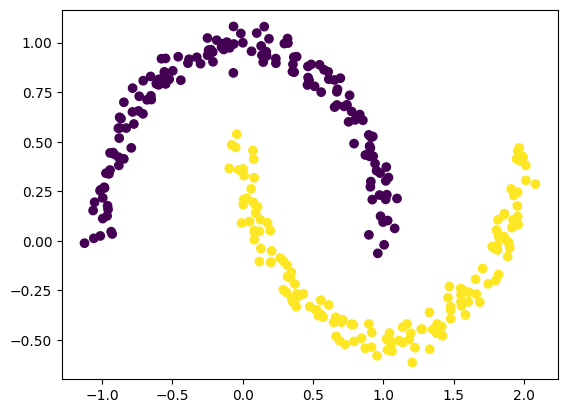

In [3]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.05)

model = DBSCAN(eps=0.2, min_samples=5)
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

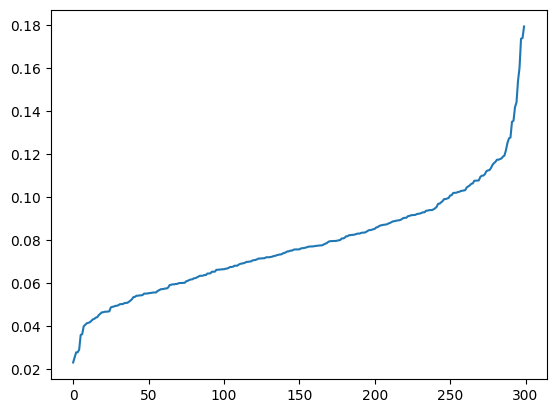

In [4]:
# eps 선택 (중요)1️⃣ 반드시 스케일링 먼저 2️⃣ eps는 데이터 스케일에 따라 달라짐
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:,4])
plt.plot(distances)
plt.show()

HDBSCAN의 핵심 아이디어

1️⃣ 다양한 eps 값으로 DBSCAN 수행
2️⃣ 그 결과를 계층적으로 구성
3️⃣ 가장 안정적인 클러스터만 선택
4️⃣ 계층적 분해

밀도가 낮은 연결부터 제거
→ 클러스터가 점점 분리됨

5️⃣ 안정성 높은 클러스터 선택

Cluster Stability 기반으로 최종 선택

In [5]:
import hdbscan
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.05)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10
)

labels = clusterer.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

ModuleNotFoundError: No module named 'hdbscan'